In [1]:
"""
This script is used to plot the interaction-QTLs
authors: Roy Oelen
"""

'\nThis script is used to plot the interaction-QTLs\nauthors: Roy Oelen\n'

In [2]:
# for checking file locations
import os
import glob
import os.path
# use warnings
import warnings
# use regex
import re
# get pandas plink info
from pandas_plink import read_plink1_bin
# for pandas
import pandas as pd
# for making the scatterplot
import seaborn as sns
import matplotlib.pyplot as plt
# for doing z score transformations
from scipy.stats import zscore

In [3]:
def get_qtl_table(omics, genotypes, omics_smf, omics_feature, variant):
    """
    Generate a plottable QTL (Quantitative Trait Loci) table by integrating omics data with genotype data.

    Parameters:
    omics (pd.DataFrame): Omics dataset with samples as columns.
    genotypes (xr.Dataset): Genotype data with samples and variants.
    omics_smf (pd.DataFrame): Sample mapping file for the omics dataset.
    omics_feature (str): Feature name in the omics dataset.
    variant (str): Variant identifier in the genotype data.

    Returns:
    pd.DataFrame: A DataFrame containing the samples, omics values, and genotype information.
    """
    # get the samples from omics
    samples_omics = list(omics.columns)
    # get the samples in the smf
    smf_samples = omics_smf['phenotype_id'].tolist()
    # finally get the omics and smf intersect
    samples_all = set(smf_samples).intersection(samples_omics)
    # get the samples that are in the genotype data
    genotype_samples = genotypes.sample.to_numpy().tolist()
    # find the genotypes for the phenotypes
    samples_in_genotypes = omics_smf[omics_smf['genotype_id'].isin(genotype_samples)]['phenotype_id']
    # finally subset to samples we have genotype data for
    samples_everything = list(set(samples_all).intersection(samples_in_genotypes.tolist()))
    # get the value for both omics
    omics_values = omics.loc[[omics_feature]][samples_everything].transpose()[omics_feature].tolist()
    # get the genotypes
    genotype_names = omics_smf.loc[samples_in_genotypes.index.tolist()]['genotype_id'].tolist()
    # get the index of the variant in the genotype object
    variant_index = genotypes.variant.to_numpy().tolist()[genotypes.snp.to_numpy().tolist().index(variant)]
    # select the unique genotype names
    genotype_names_unique = list(set(genotype_names))
    # get the values
    genotype_values = genotypes.sel(sample = genotype_names_unique, variant = variant_index).to_numpy()
    # make unique samples and respective genotypes into dataframe
    genotypeid_to_genotype = pd.DataFrame({'genotype_id' : genotype_names_unique, 'genotype' : genotype_values})
    # make plot frame
    plot_frame = pd.DataFrame({'sample' : samples_everything, 'omics' : omics_values})
    # join to the smf on the phenotype_id
    plot_frame = plot_frame.merge(omics_smf, how = 'left', left_on = 'sample', right_on = 'phenotype_id')
    # and then onto the genotypes
    plot_frame = plot_frame.merge(genotypeid_to_genotype, how = 'left', left_on = 'genotype_id', right_on = 'genotype_id')
    return plot_frame


In [4]:
# location of plink input files
plink_files_base_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/genotype/imputed_hg38_all_anc.bed'
# read the original genotype data
genotypes = read_plink1_bin(plink_files_base_loc)

Mapping files: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:42<00:00, 34.14s/it]


In [5]:
# location of the expression data
rna_data_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/monocyte.qtlInput.txt.gz'
# read the RNA data
rna_data = pd.read_csv(rna_data_loc, header = 0, sep = '\t', index_col = 0)

In [6]:
# sample mapping information
rna_smf_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/smf.txt'
# read
rna_smf = pd.read_csv(rna_smf_loc, header = 0, sep = '\t')

In [9]:
# location of the covariates
rna_covars_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/interaction_eqtl/sc-eqtlgen/input/L1/combined/monocyte.qtlInput.Pcs.txt.gz'
# read
rna_covars = pd.read_csv(rna_covars_loc, header = 0, sep = '\t', index_col = 0)

In [29]:
# get stimulated samples
stim_samples = rna_covars[rna_covars['inflammation_final'] == 1].index.tolist()
# and unstimulated samples
unstim_samples = rna_covars[rna_covars['inflammation_final'] == 0].index.tolist()
# and join with what we actually have
stim_samples = list(set(stim_samples).intersection(rna_data.columns.tolist()))
unstim_samples = list(set(unstim_samples).intersection(rna_data.columns.tolist()))

In [43]:
# get the eQTL table for both both conditions
eqtl_table = get_qtl_table(omics=rna_data, 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='LARP1', 
                 variant='5:154685935:G:A')
# add a binary genotype
eqtl_table['alleles'] = eqtl_table['genotype'].map({0.0 : 'GG', 1.0 : 'GA', 2.0 : 'AA'})
# and sort
eqtl_table = eqtl_table.sort_values('alleles')

# now the same for the stim and unstim separately
eqtl_table_stim = get_qtl_table(omics=rna_data[stim_samples], 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='LARP1', 
                 variant='5:154685935:G:A')
eqtl_table_stim['alleles'] = eqtl_table_stim['genotype'].map({0.0 : 'GG', 1.0 : 'GA', 2.0 : 'AA'})
eqtl_table_stim = eqtl_table_stim.sort_values('alleles')
eqtl_table_unstim = get_qtl_table(omics=rna_data[unstim_samples], 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='LARP1', 
                 variant='5:154685935:G:A')
eqtl_table_unstim['alleles'] = eqtl_table_unstim['genotype'].map({0.0 : 'GG', 1.0 : 'GA', 2.0 : 'AA'})
eqtl_table_unstim = eqtl_table_unstim.sort_values('alleles')


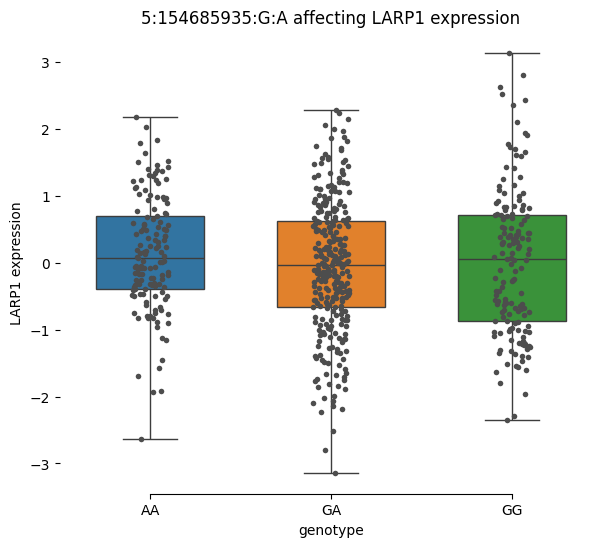

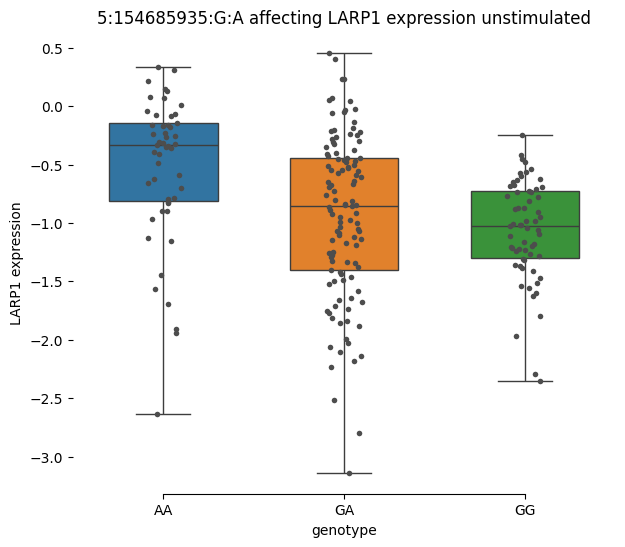

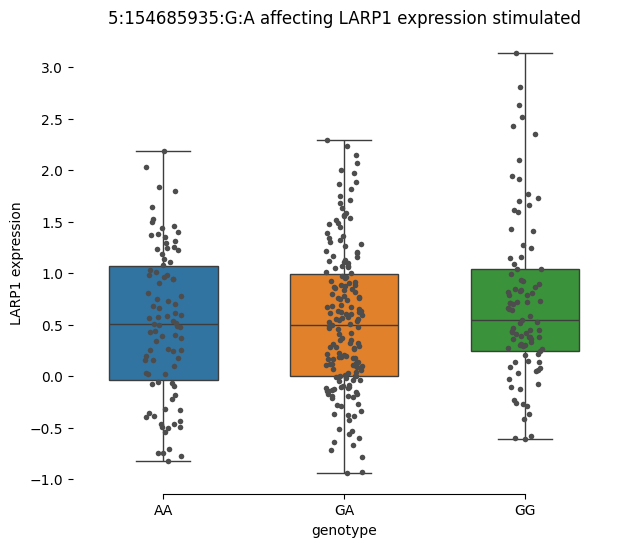

In [44]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_table, whis=[0, 100], width=.6).set(title = ' '.join(['5:154685935:G:A', 'affecting', 'LARP1', 'expression']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='LARP1 expression', xlabel='genotype')
sns.despine(trim=True, left=True)

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_table_unstim, whis=[0, 100], width=.6).set(title = ' '.join(['5:154685935:G:A', 'affecting', 'LARP1', 'expression', 'unstimulated']))
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_table_unstim, size=4, color=".3", linewidth=0)
ax.xaxis.grid(False)
ax.set(ylabel='LARP1 expression', xlabel='genotype')
sns.despine(trim=True, left=True)

# set plots
f, ax = plt.subplots(figsize=(7, 6))            
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_table_stim, whis=[0, 100], width=.6).set(title = ' '.join(['5:154685935:G:A', 'affecting', 'LARP1', 'expression', 'stimulated']))
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_table_stim, size=4, color=".3", linewidth=0)
ax.xaxis.grid(False)
ax.set(ylabel='LARP1 expression', xlabel='genotype')
sns.despine(trim=True, left=True)
